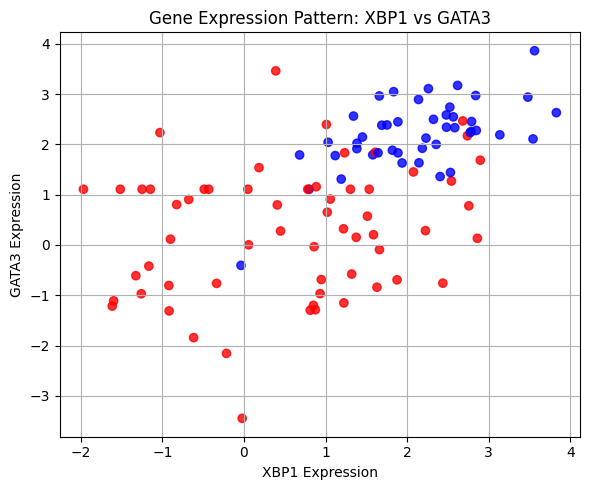

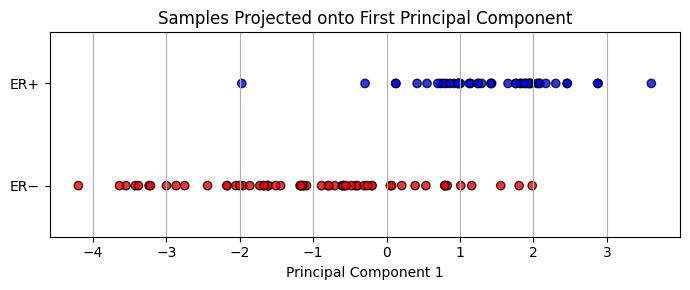

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gzip

# Load class labels from TSV file (1=ER+, 0=ER-)
estrogen_receptor_status = pd.read_csv("data/class.tsv", header=None, names=["ERStatus"])["ERStatus"]

# Load gene metadata from gzipped TSV file
gene_metadata = pd.read_csv("data/columns.tsv.gz", sep="\t", comment="#")

# Extract IDs for specific genes of interest (XBP1 and GATA3)
target_gene_ids = gene_metadata.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]["ID"].astype(str).tolist()

# Load gene expression data from gzipped TSV file
with gzip.open("data/filtered.tsv.gz", "rt") as expression_file:
    gene_expression_data = pd.read_csv(expression_file, sep="\t")

gene_expression_data.columns = gene_expression_data.columns.str.strip()

target_gene_expression = gene_expression_data[target_gene_ids].copy()
target_gene_expression.columns = ["XBP1", "GATA3"]

plt.figure(figsize=(6, 5))
color_mapping = estrogen_receptor_status.map({1: "blue", 0: "red"})
plt.scatter(target_gene_expression["XBP1"], target_gene_expression["GATA3"], c=color_mapping, alpha=0.8)
plt.xlabel("XBP1 Expression")
plt.ylabel("GATA3 Expression")
plt.title("Gene Expression Pattern: XBP1 vs GATA3")
plt.grid(True)
plt.tight_layout()
plt.show()

# Perform Principal Component Analysis (PCA) with 1 component
pca_model = PCA(n_components=1)
principal_component = pca_model.fit_transform(target_gene_expression)

er_status_values = estrogen_receptor_status.values

plt.figure(figsize=(7, 3))
plt.scatter(principal_component, er_status_values, c=color_mapping, alpha=0.8, edgecolor='k')
plt.yticks([0, 1], ["ER−", "ER+"])
plt.ylim(-0.5, 1.5)
plt.xlabel("Principal Component 1")
plt.title("Samples Projected onto First Principal Component")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()
